# Eclipse doppler lidar stats

This notebook calculates the vertical velocity stats associated with the eclipse. In this program, we're going to take a 30 min running average and find the variance associated with that.

## Preliminary matters

Start with the key info, like paths, dates, etc.

Load the relevant modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import netCDF4
from scipy import interpolate as interp

In [6]:
dataPath = '/data/eclipse/dlfpt/'


eclipseDates = np.array([20120521,20170821, 20231014, 20240408])
eclipseTimes = np.array([1.5, 18+3/60, 16+47/60 ,18+47/60])
eclipseObscuration = np.array([85.8, 88.5, 72.8, 90.4])/100

eclipseSites = np.array(['C1','E32','E37','E39','E41'])
eclipseFacilities = np.array(['sgp','sgp','sgp','sgp','sgp'])

# eclipseDates = np.array([20120520, 20141023, 20170821, 20210610])
# eclipseTimes = np.array([11+13/60, 19+55/60, 17+29/60, 10+57/60])
# eclipseObscuration = np.array([0.482, 0.695, 0.335,0.849])
# nsaTimeZone = np.array([-9,-9,-9,-9])
# eclipseSites= np.array(['C1'])
# eclipseFacilities = np.array(['nsa'])





plotAllFigs = 0
    
timeNew = np.linspace(-4,4,3600*8+1)
heightNew = np.arange(15,2025,30)

wPrime = np.zeros((len(timeNew), len(heightNew)))
wVar = np.zeros((len(timeNew), len(heightNew), len(eclipseSites)*len(eclipseDates)))
saveDate = np.zeros(len(timeNew) * len(heightNew))


Define a couple of functions: one to read the DL files, and one to find the index of the nearest value.

In [3]:
def readDL(f):

    ds = netCDF4.Dataset(f)
    
    class out:
        
        unixTime = ds['base_time'][:] + ds['time_offset'][:]
        time = ds['time'][:]/3600 # Hours UTC 
        height = ds['range'][:]
        w = ds['radial_velocity'][:]
        qc_w = ds['qc_radial_velocity'][:]
        intensity = ds['intensity'][:]
        back = ds['attenuated_backscatter'][:]
        
        
    out.w[np.where(out.qc_w != 0)] = np.nan
    
    return out

def findNearest(array,value):
    idx = (np.abs(array-value)).argmin()
    return idx  


## Data collection

The SGP vertical velocity observations are in hourly files. We want to join all of the data together into a uniform structure. This is being updated to act as a function

In [4]:
def collectDL(eFacility, eSite, eDate):

    iter = 0    
    
    for file in sorted(glob.iglob(dataPath + '/' + eFacility+ '*' + eSite + '*' + str(eDate) + '*.cdf')):
        
        dli = readDL(file)
        if iter ==0:

            class dl:

                unixTime = np.array(dli.unixTime)
                time =  np.array(dli.time)
                height =  np.array(dli.height)
                w =  np.array(dli.w)
                intensity = np.array(dli.intensity)
                back = np.array(dli.back)


        else:

            dl.unixTime = np.concatenate((dl.unixTime, dli.unixTime))
            dl.time = np.concatenate((dl.time, dli.time))
            dl.w = np.concatenate((dl.w, dli.w))
            dl.intensity = np.concatenate((dl.intensity, dli.intensity))
            dl.back = np.concatenate((dl.back, dli.back))

        iter = iter+1
        
  
    return dl

## Statistical analysis

To obtain the vertical veolicty variance, we need to first come up with a running average.

First we'll need to interpolate the data to a constant 1 s grid. 

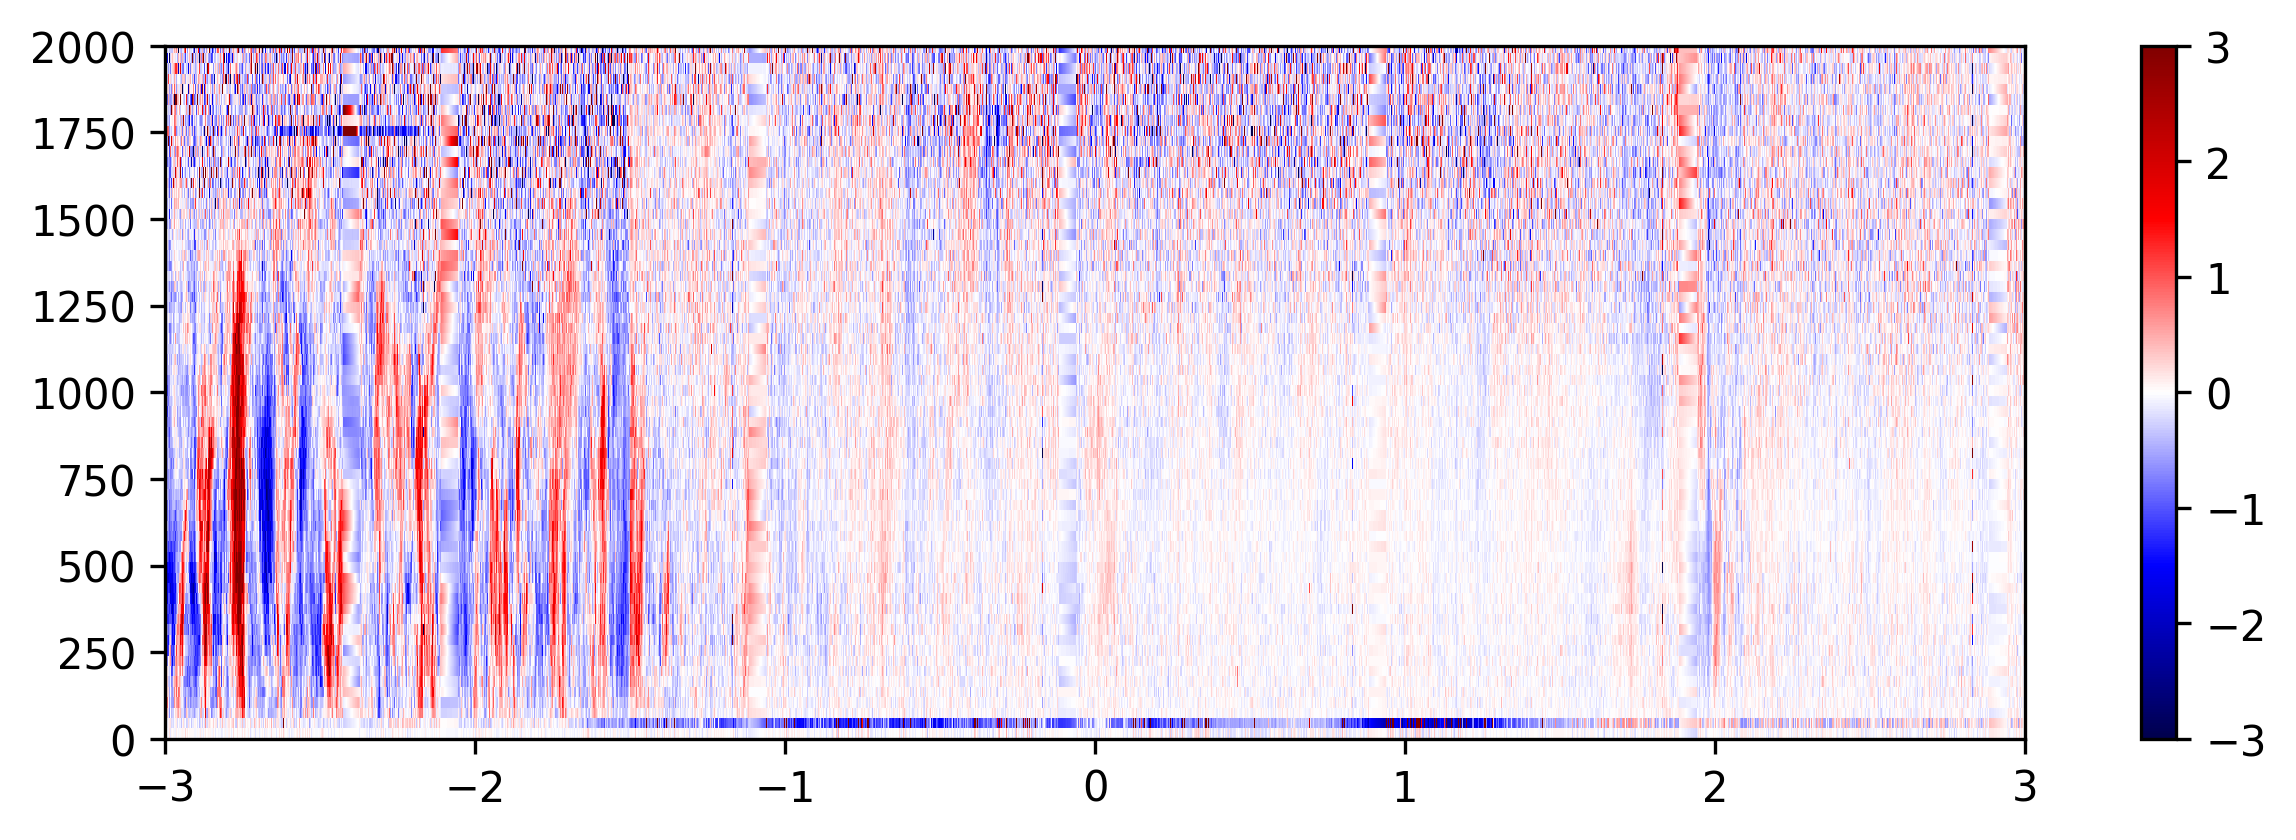

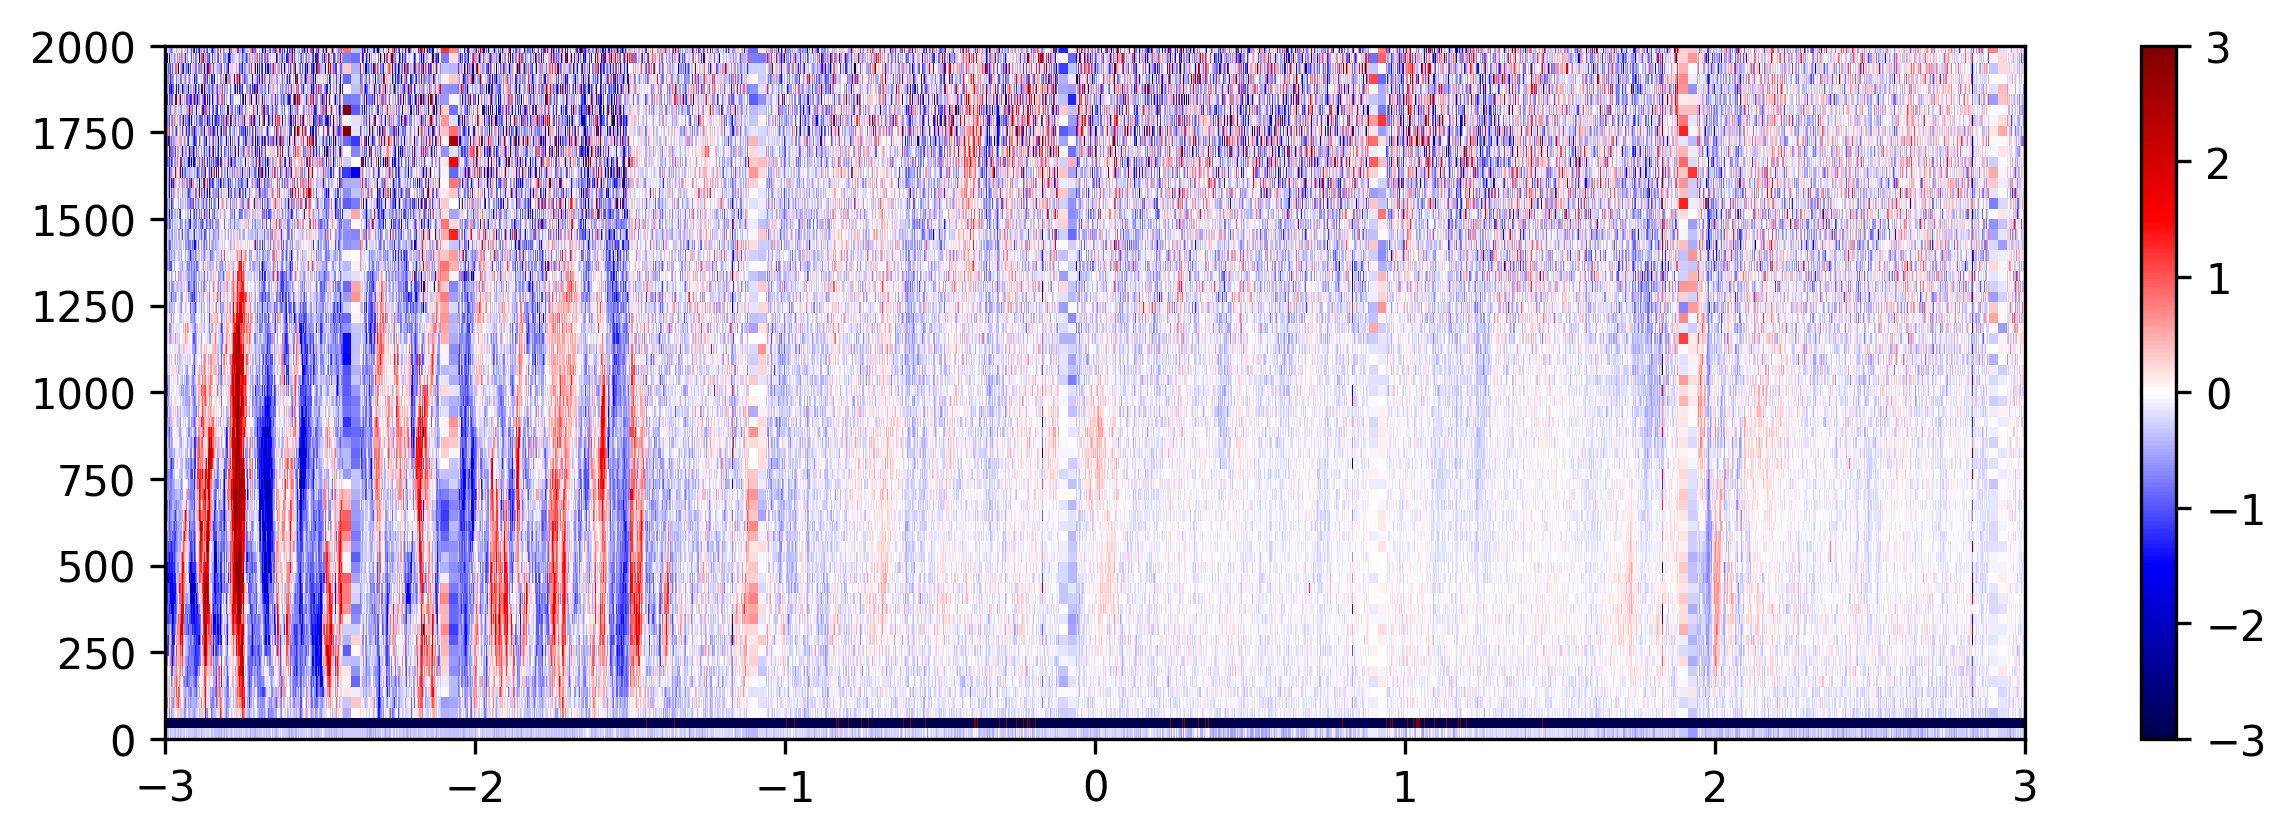

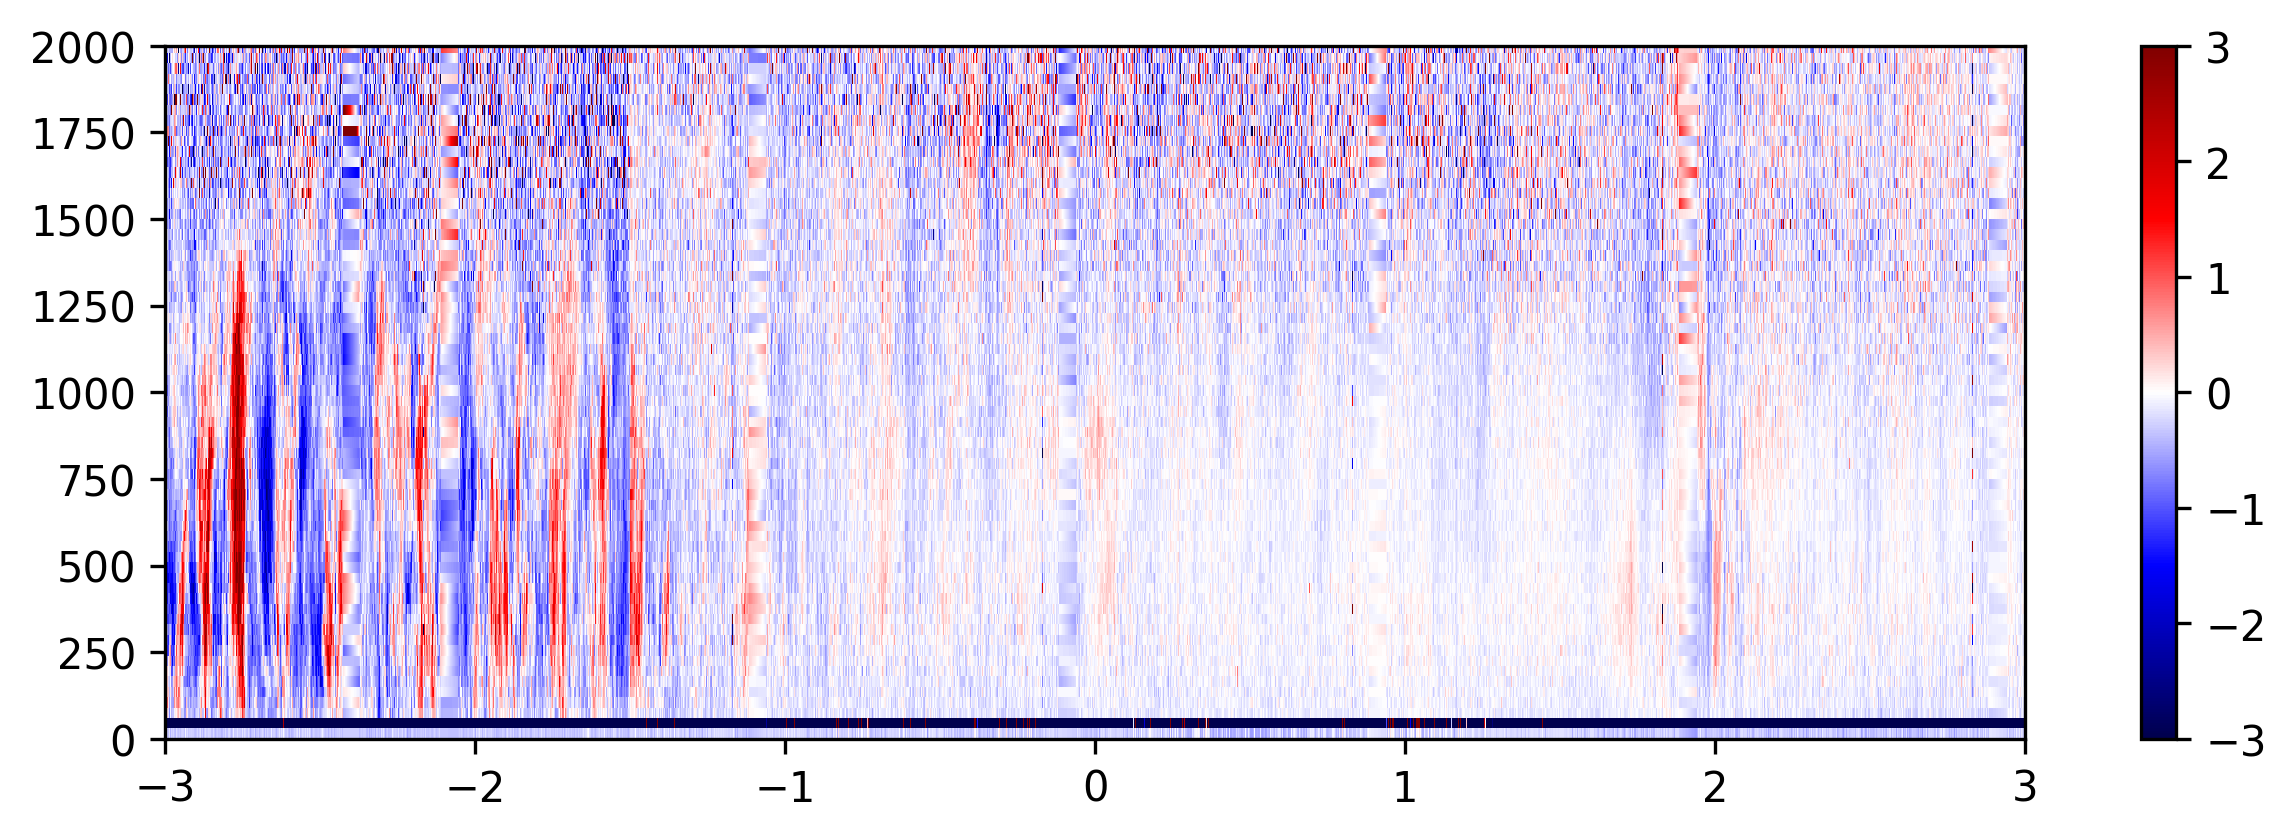

/var/folders/sc/bkdnv16d7vbgn44gdn17nmr40000gn/T/ipykernel_9393/1291117145.py:78: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')


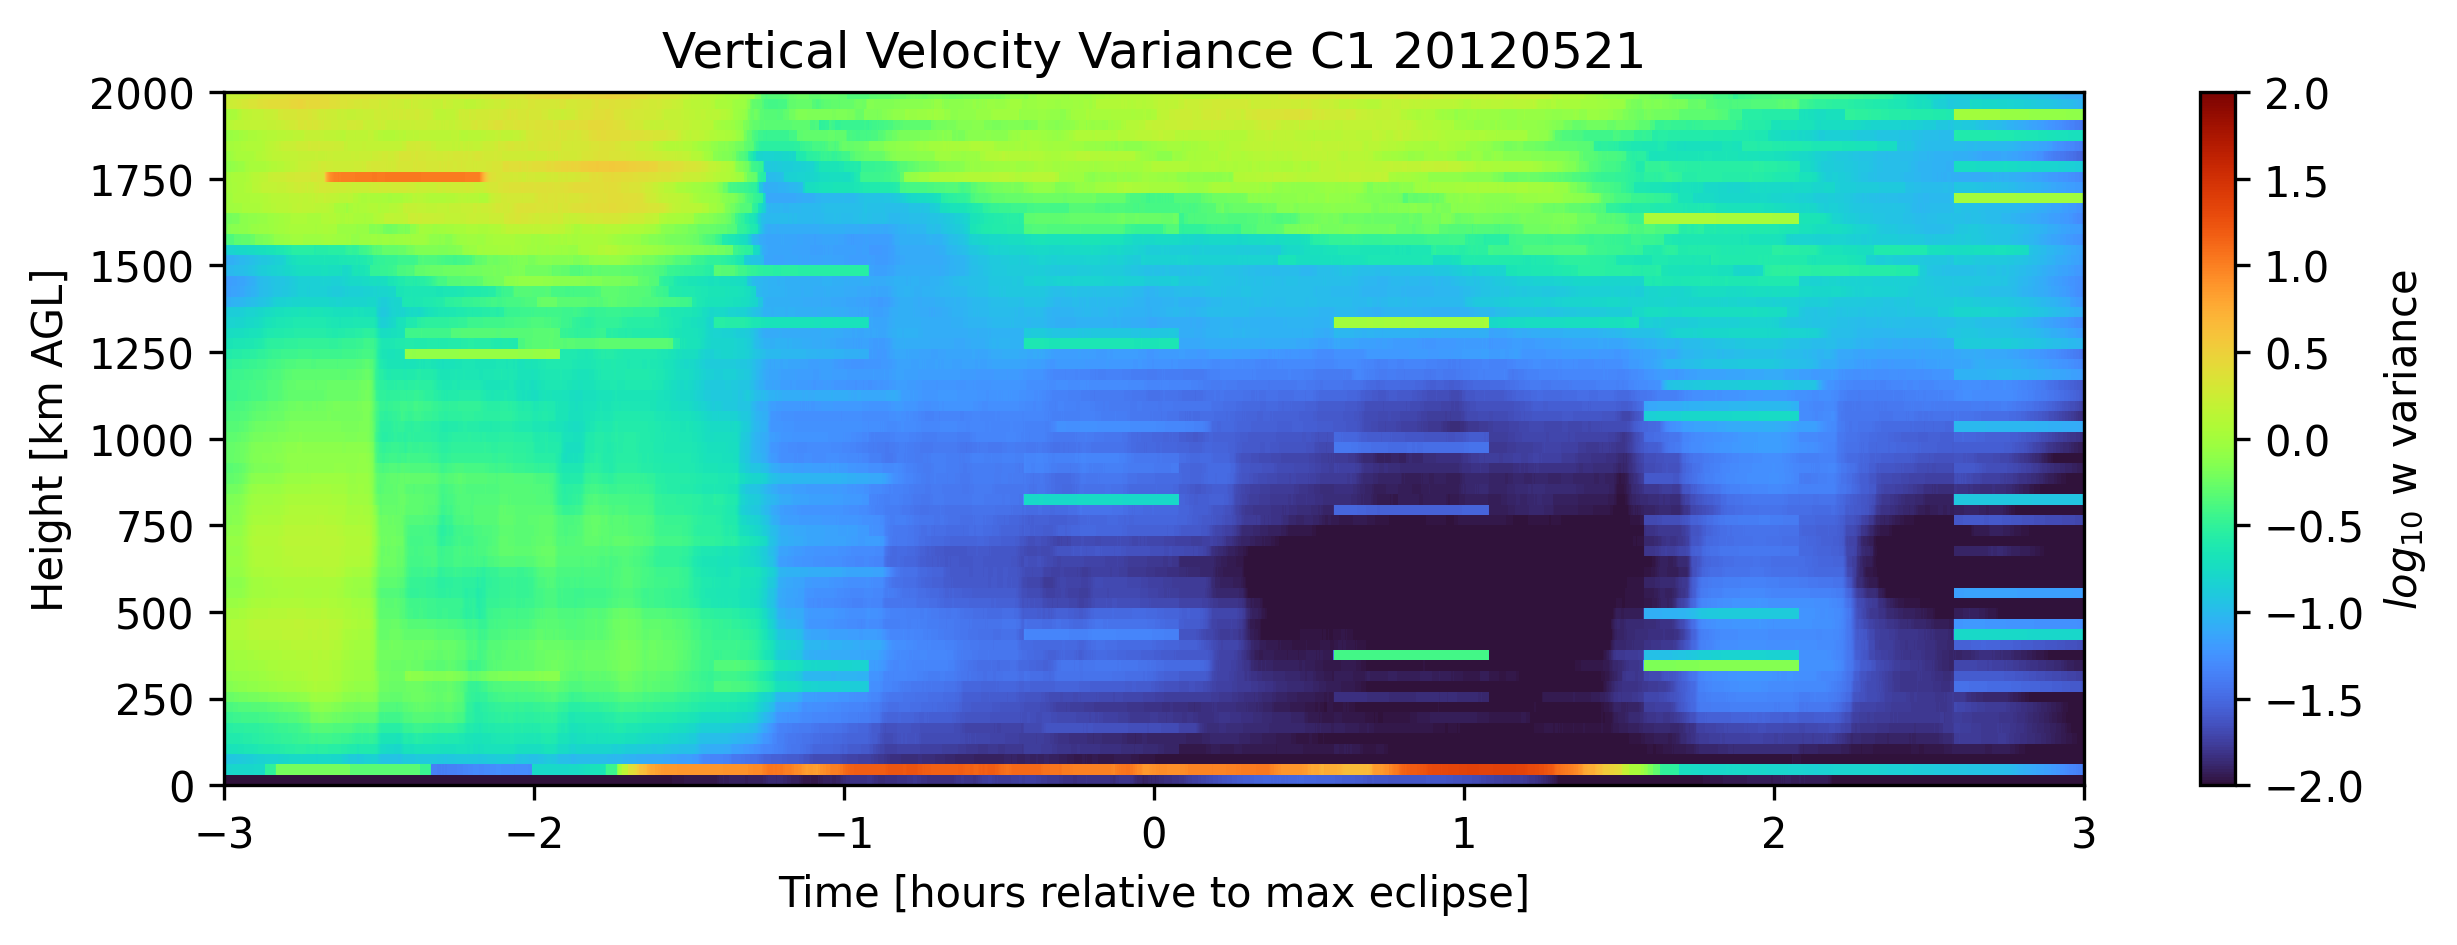

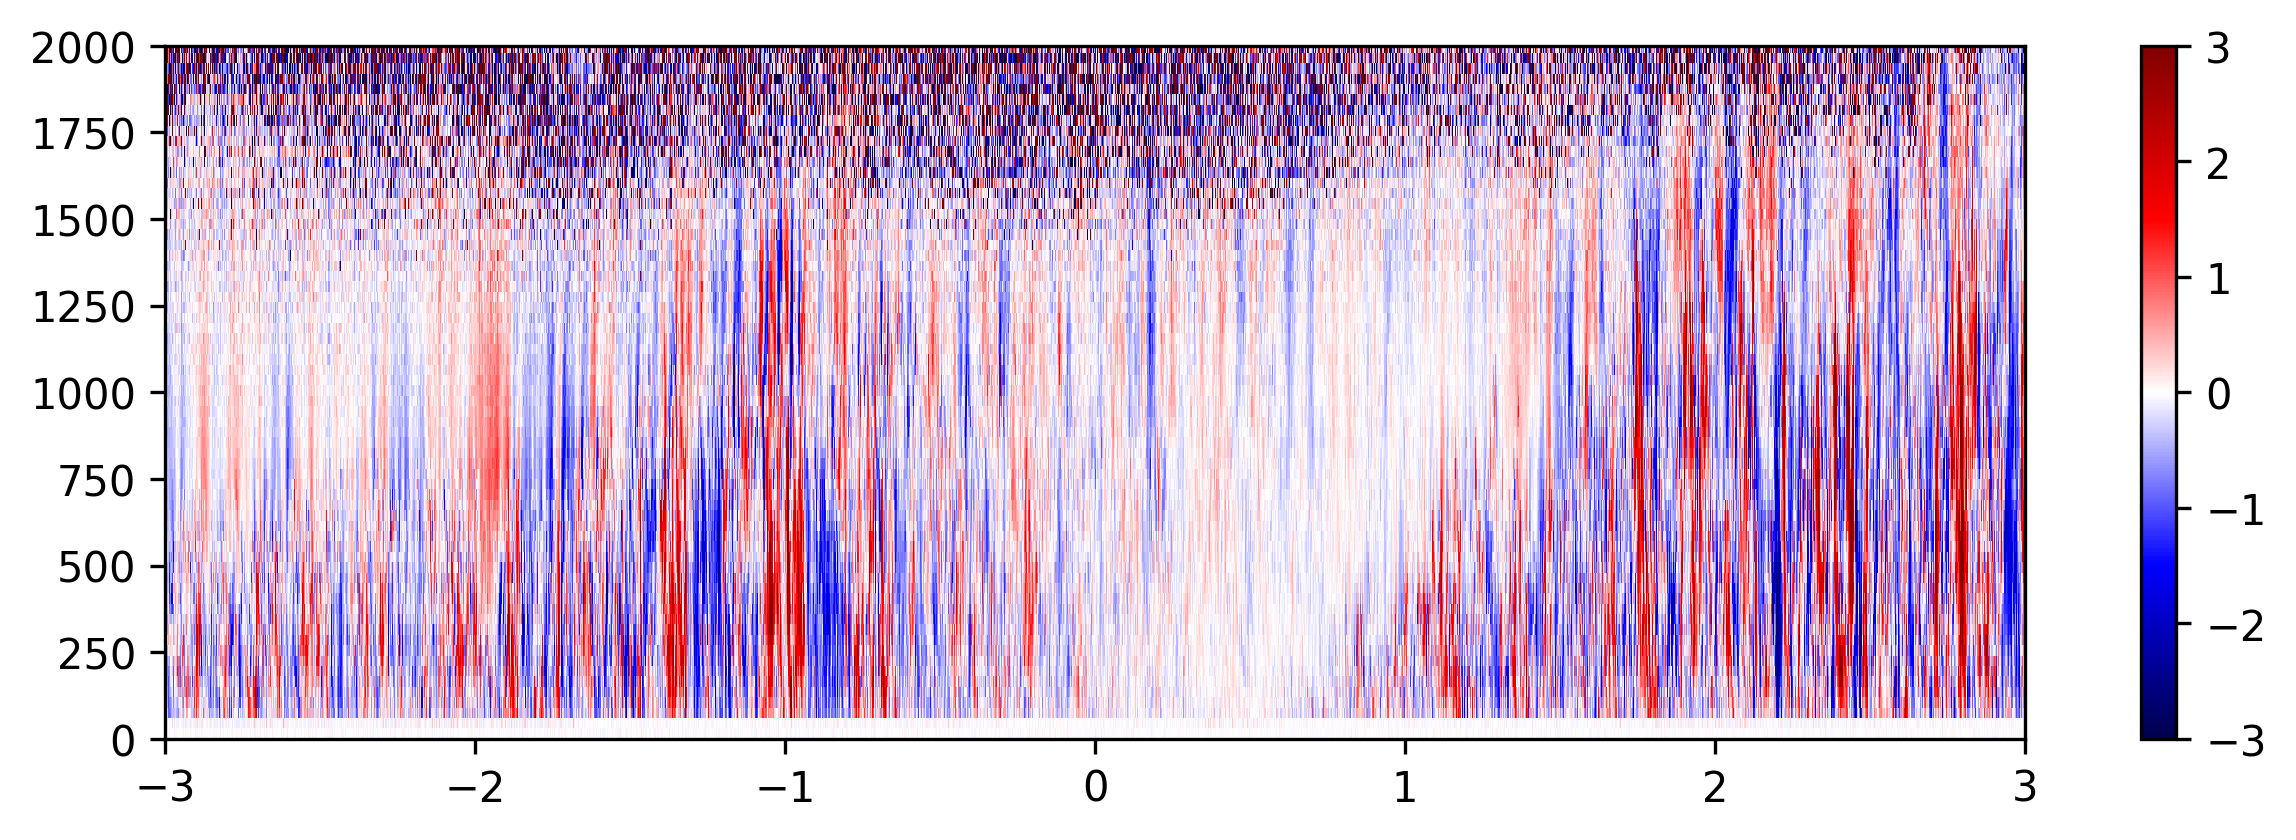

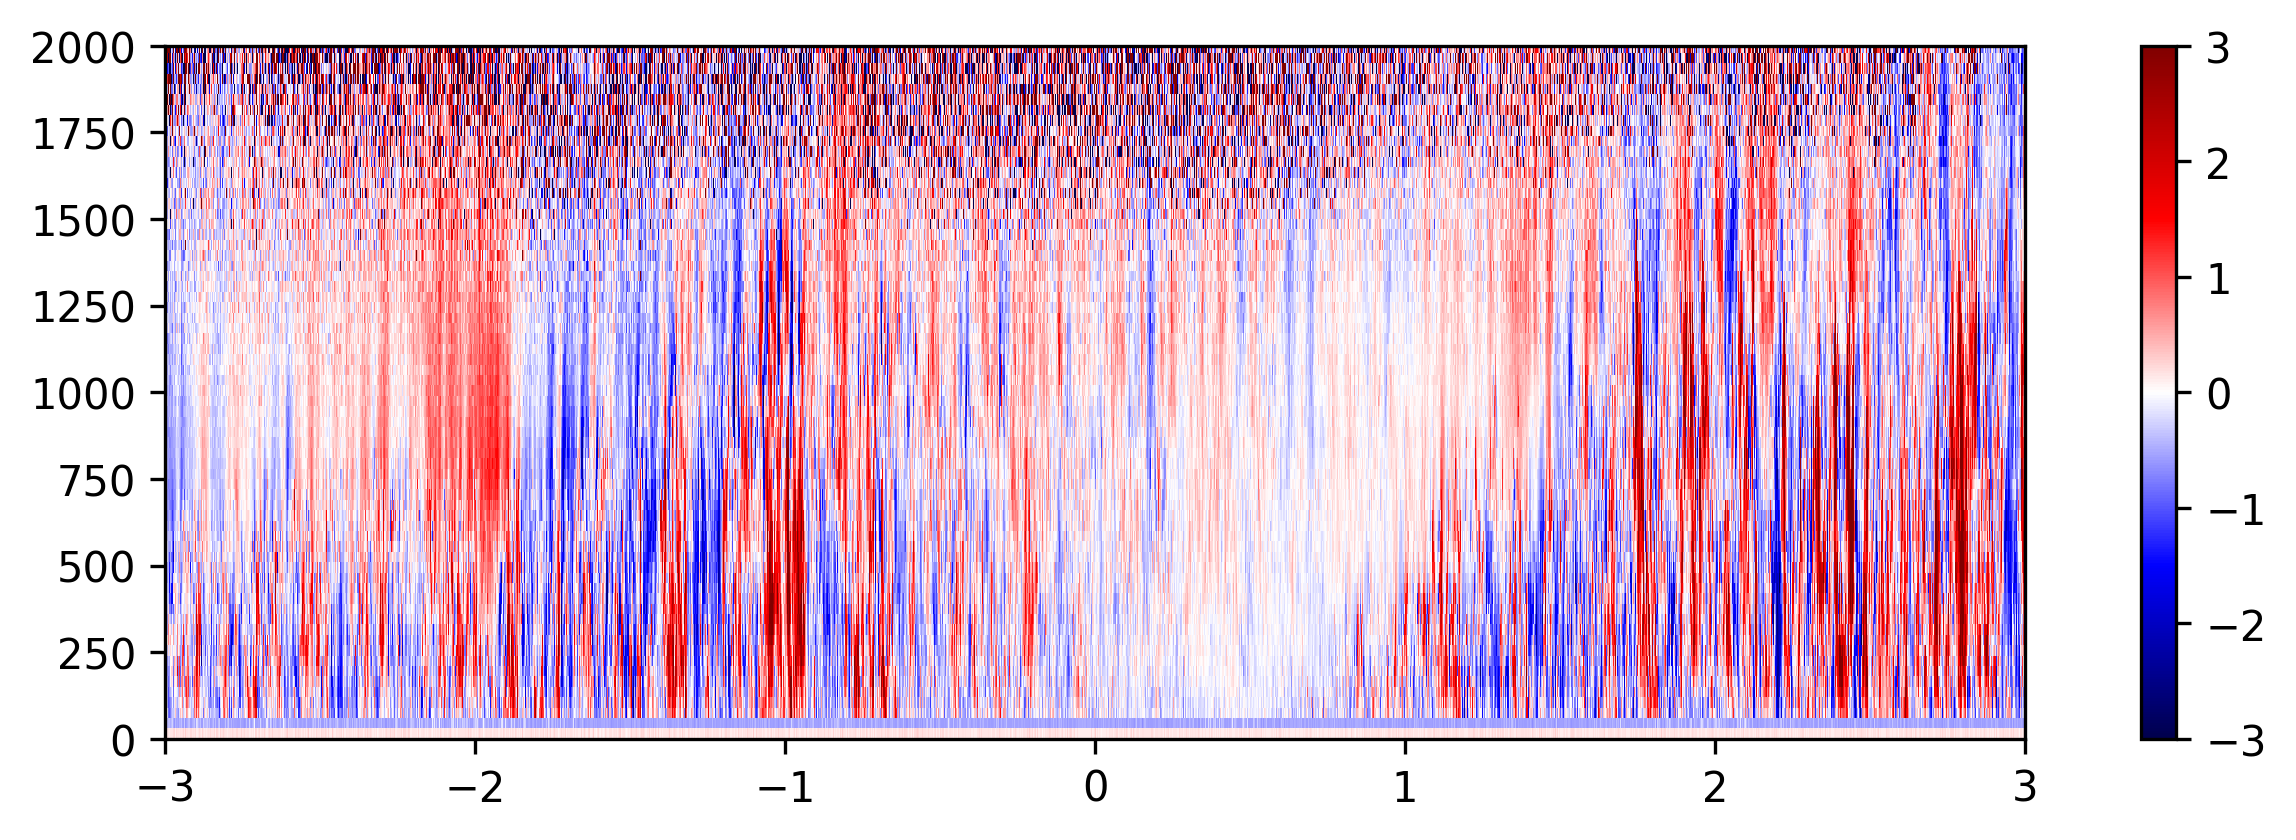

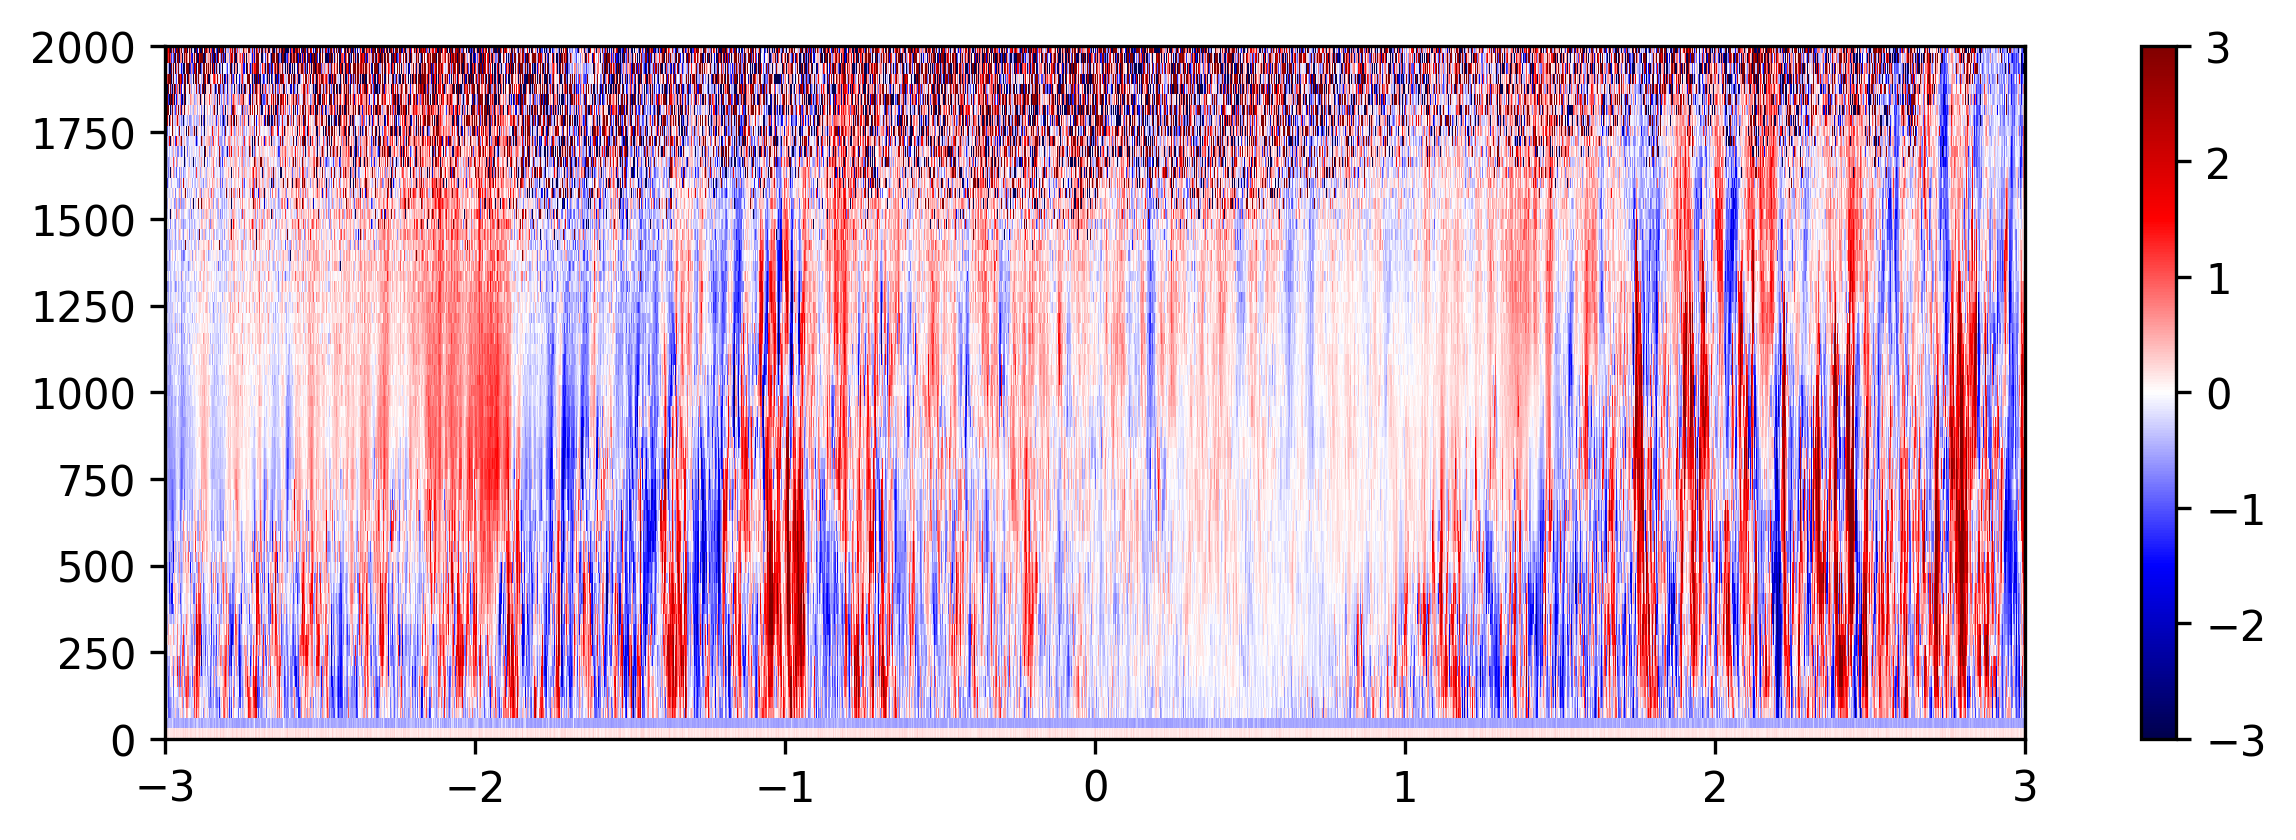

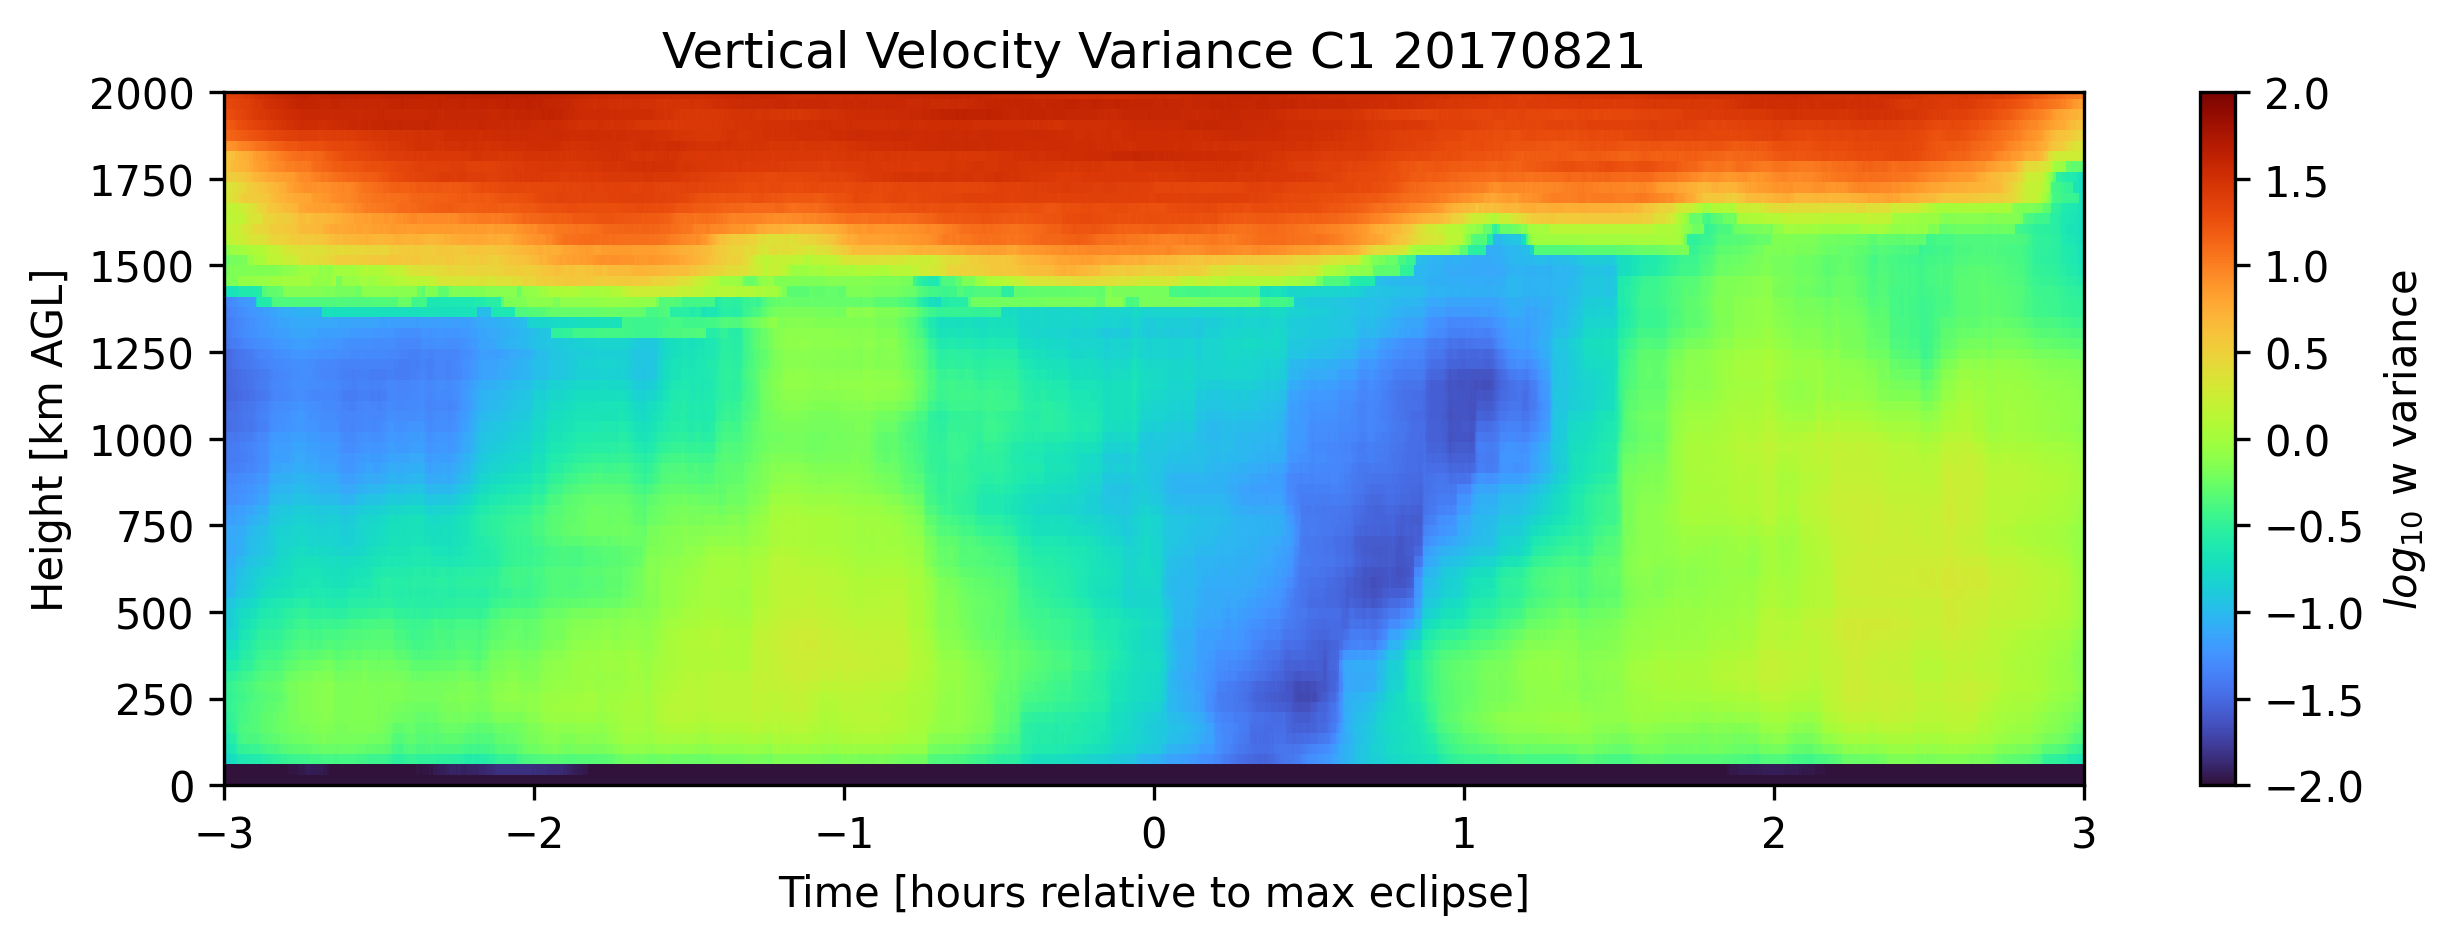

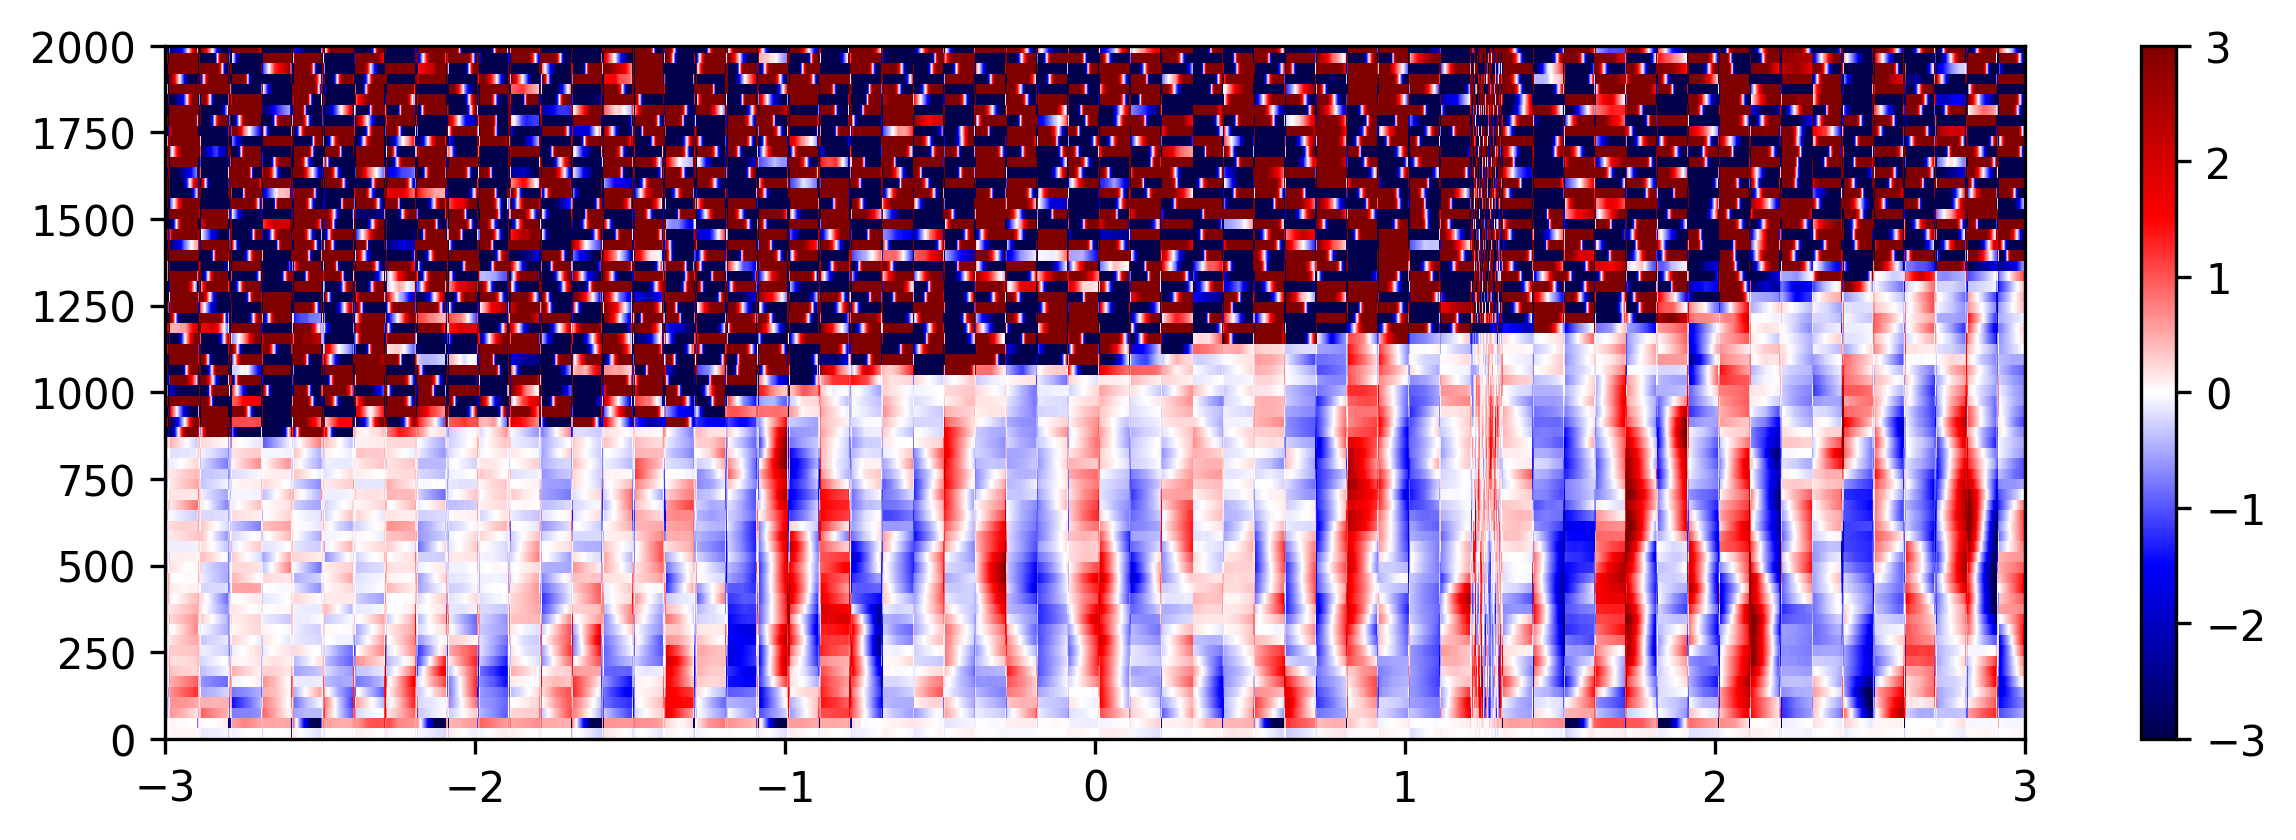

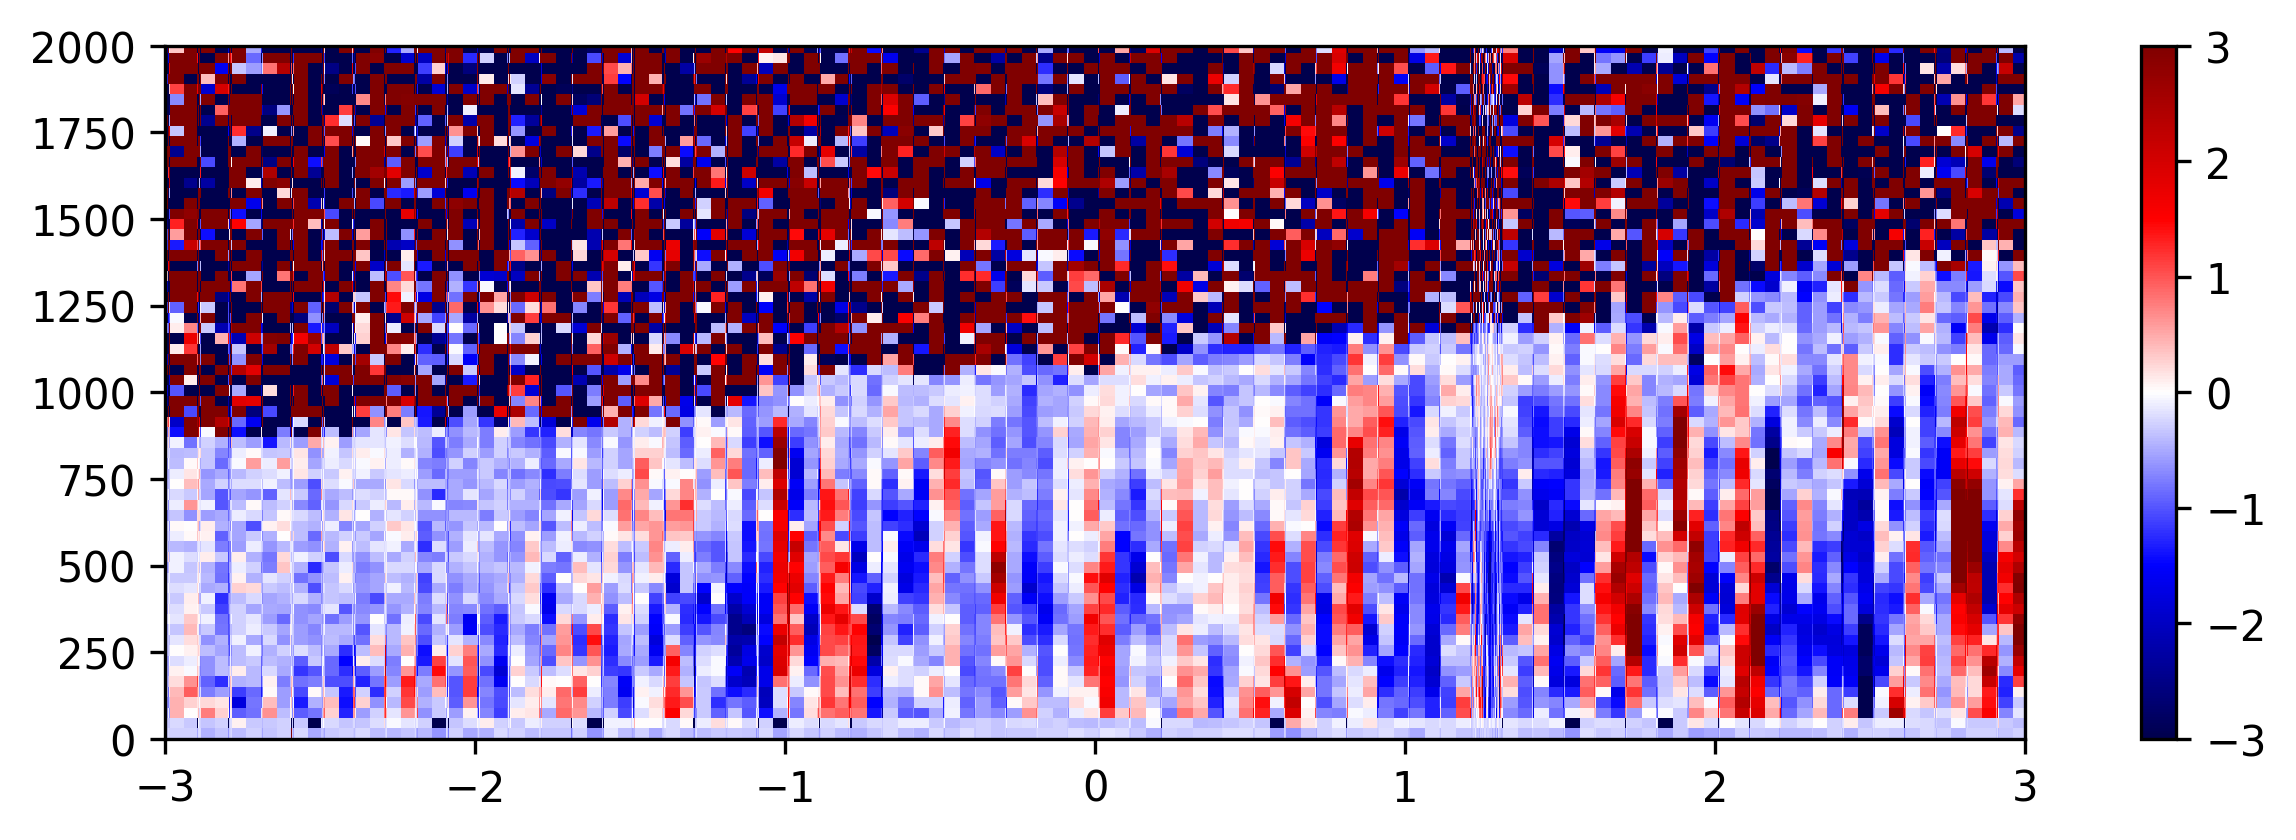


KeyboardInterrupt



In [5]:
ctr = 0

for g in np.arange(len(eclipseSites)):


    for h in np.arange(len(eclipseDates)):
        
        

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
            
            dl.time = dl.time - eclipseTimes[h]

        except:
            
            ctr=ctr+1
            continue
        
        interpFunc = interp.RectBivariateSpline(dl.time, dl.height, dl.w,kx=1, ky=1)

        #wNew = interpFunc(timeNew, dl.height)
        wNew = interpFunc(timeNew, heightNew)


        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)

        for i in range(totalStartIdx, totalEndIdx):
    
       
            meanW = np.mean(wNew[i-900:i+900,:],axis=0)
            wPrime[i,:] = wNew[i,:]-meanW

        for i in range(totalStartIdx, totalEndIdx):

            wVar[i,:,ctr] = np.var(wPrime[i-900:i+900,:],axis=0)


        if plotAllFigs == 1:
            plt.figure(figsize=(10, 3), dpi=300)
            plt.pcolormesh(timeNew, heightNew, np.transpose(wPrime),cmap = 'seismic')
            plt.colorbar()
            plt.clim([-3, 3])
            plt.ylim([0,2000])
            plt.xlim([-3,3])
            plt.show()

            plt.figure(figsize=(10, 3), dpi=300)
            plt.pcolormesh(dl.time, dl.height, np.transpose(dl.w),cmap = 'seismic')
            plt.colorbar()
            plt.clim([-3, 3])
            plt.ylim([0,2000])
            plt.xlim([-3,3])
            plt.show()

            plt.figure(figsize=(10, 3), dpi=300)
            plt.pcolormesh(timeNew, heightNew, np.transpose(wNew),cmap = 'seismic')
            plt.colorbar()
            plt.clim([-3, 3])
            plt.ylim([0,2000])
            plt.xlim([-3,3])
            plt.show()

        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
        cbar = plt.colorbar()
        cbar.set_label('$log_{10}$ w variance')
        plt.title('Vertical Velocity Variance ' + eclipseSites[g] + ' ' + str(eclipseDates[h]))
        plt.clim([-2, 2])
        plt.ylim([0,2000])
        plt.xlim([-3,3])
        plt.xlabel('Time [hours relative to max eclipse]')
        plt.ylabel('Height [km AGL]')
        plt.show()

        saveDate[ctr] = eclipseDates[h]
        ctr = ctr+1


## Collective analysis

Here is where we start putting the individual cases together.

In [ ]:
plt.figure(figsize=(30, 20), dpi=300)

ctr=0

for g in np.arange(len(eclipseSites)):

    for h in np.arange(len(eclipseDates)):
        
        plt.subplot(len(eclipseSites),len(eclipseDates),ctr+1)
        plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
        cbar = plt.colorbar()
        cbar.set_label('$log_{10}$ w variance')
        plt.title('Vertical Velocity Variance ' + eclipseSites[g] + ' ' + str(eclipseDates[h]))
        plt.clim([-2, 2])
        plt.ylim([0,2000])
        plt.xlim([-3,3])
        if g==len(eclipseSites)-1:
            plt.xlabel('Time [hours relative to max eclipse]')
        plt.ylabel('Height [km AGL]')
        #plt.gca().set_facecolor((1-eclipseObscuration[h])*np.array([1, 1, 1]))
        ctr=ctr+1
        
plt.show()

/Users/timw/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/timw/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


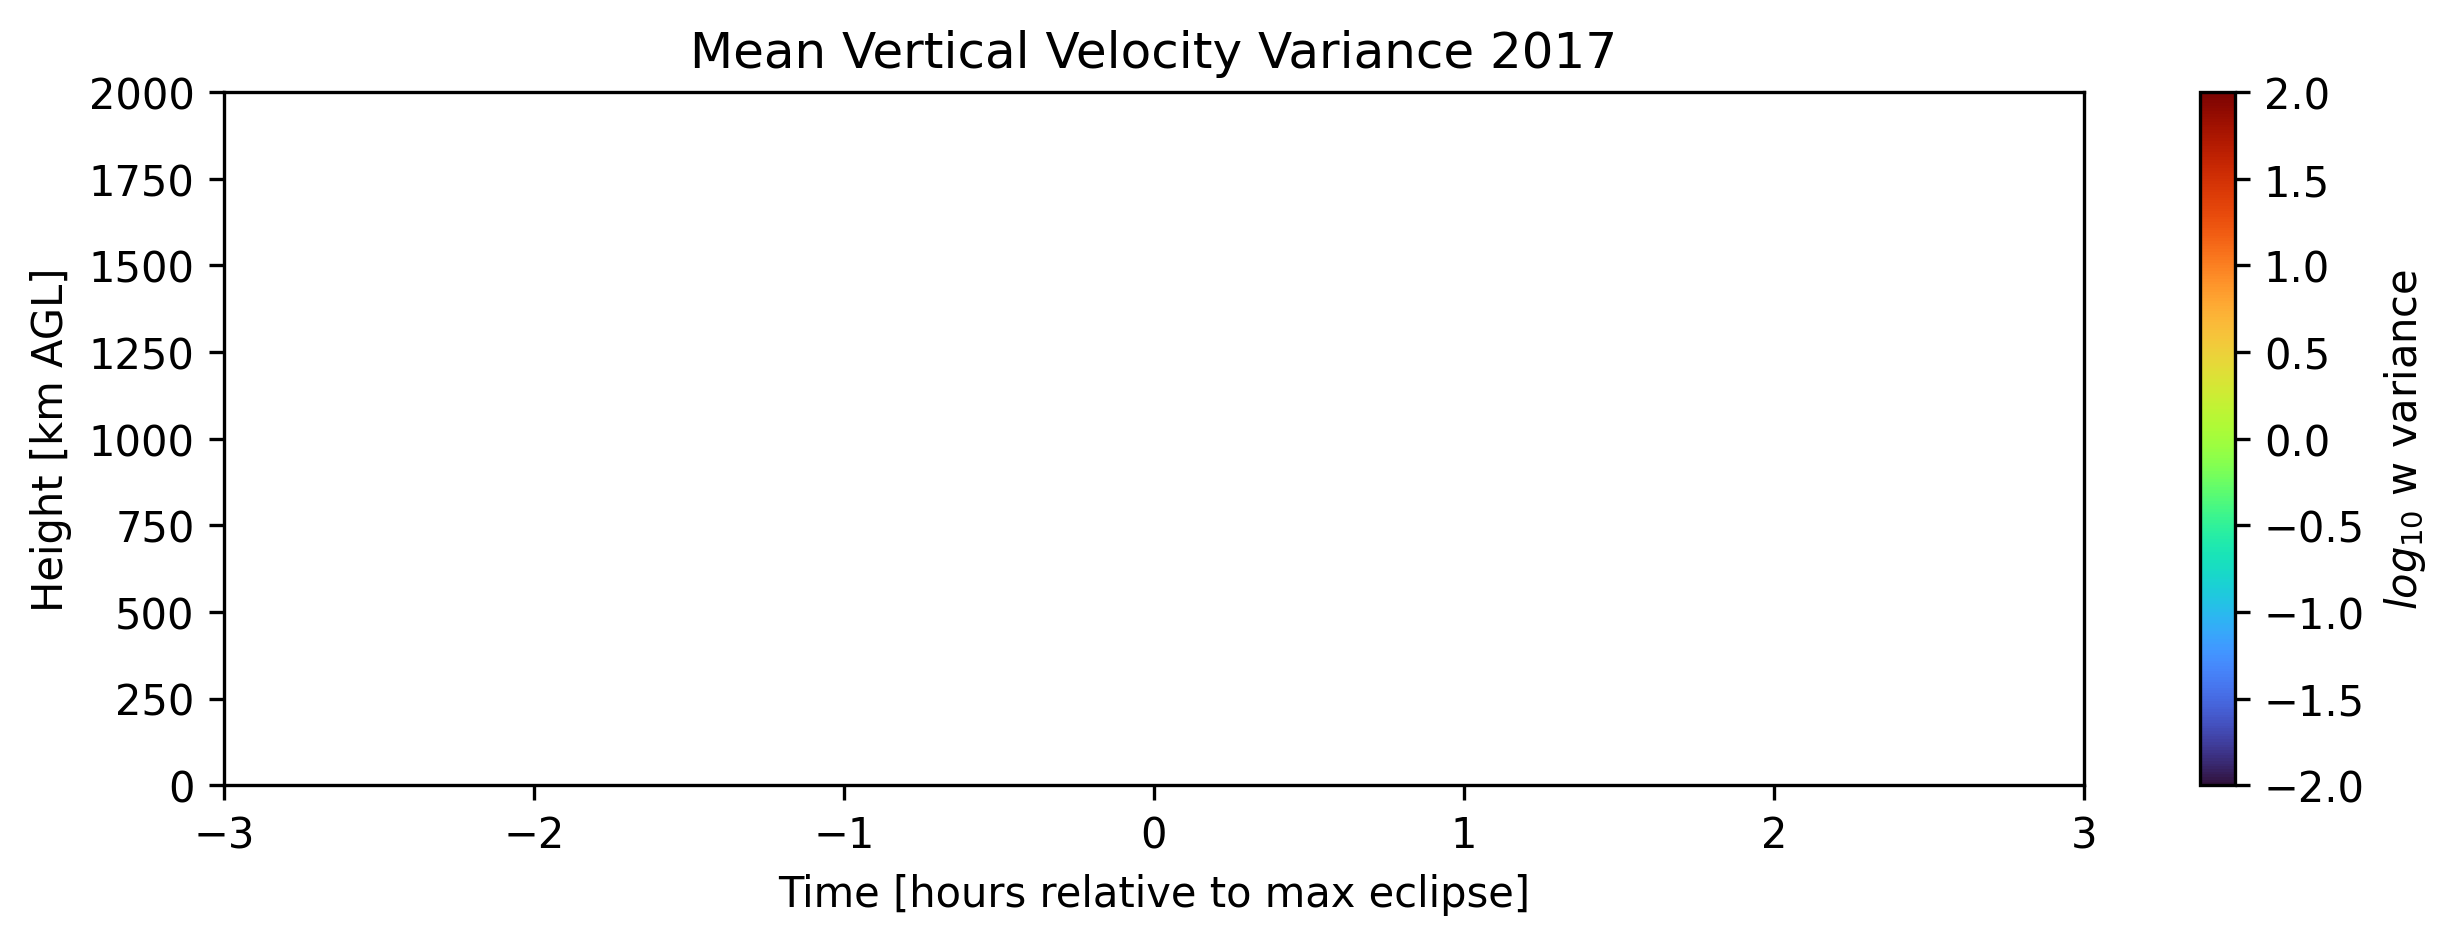

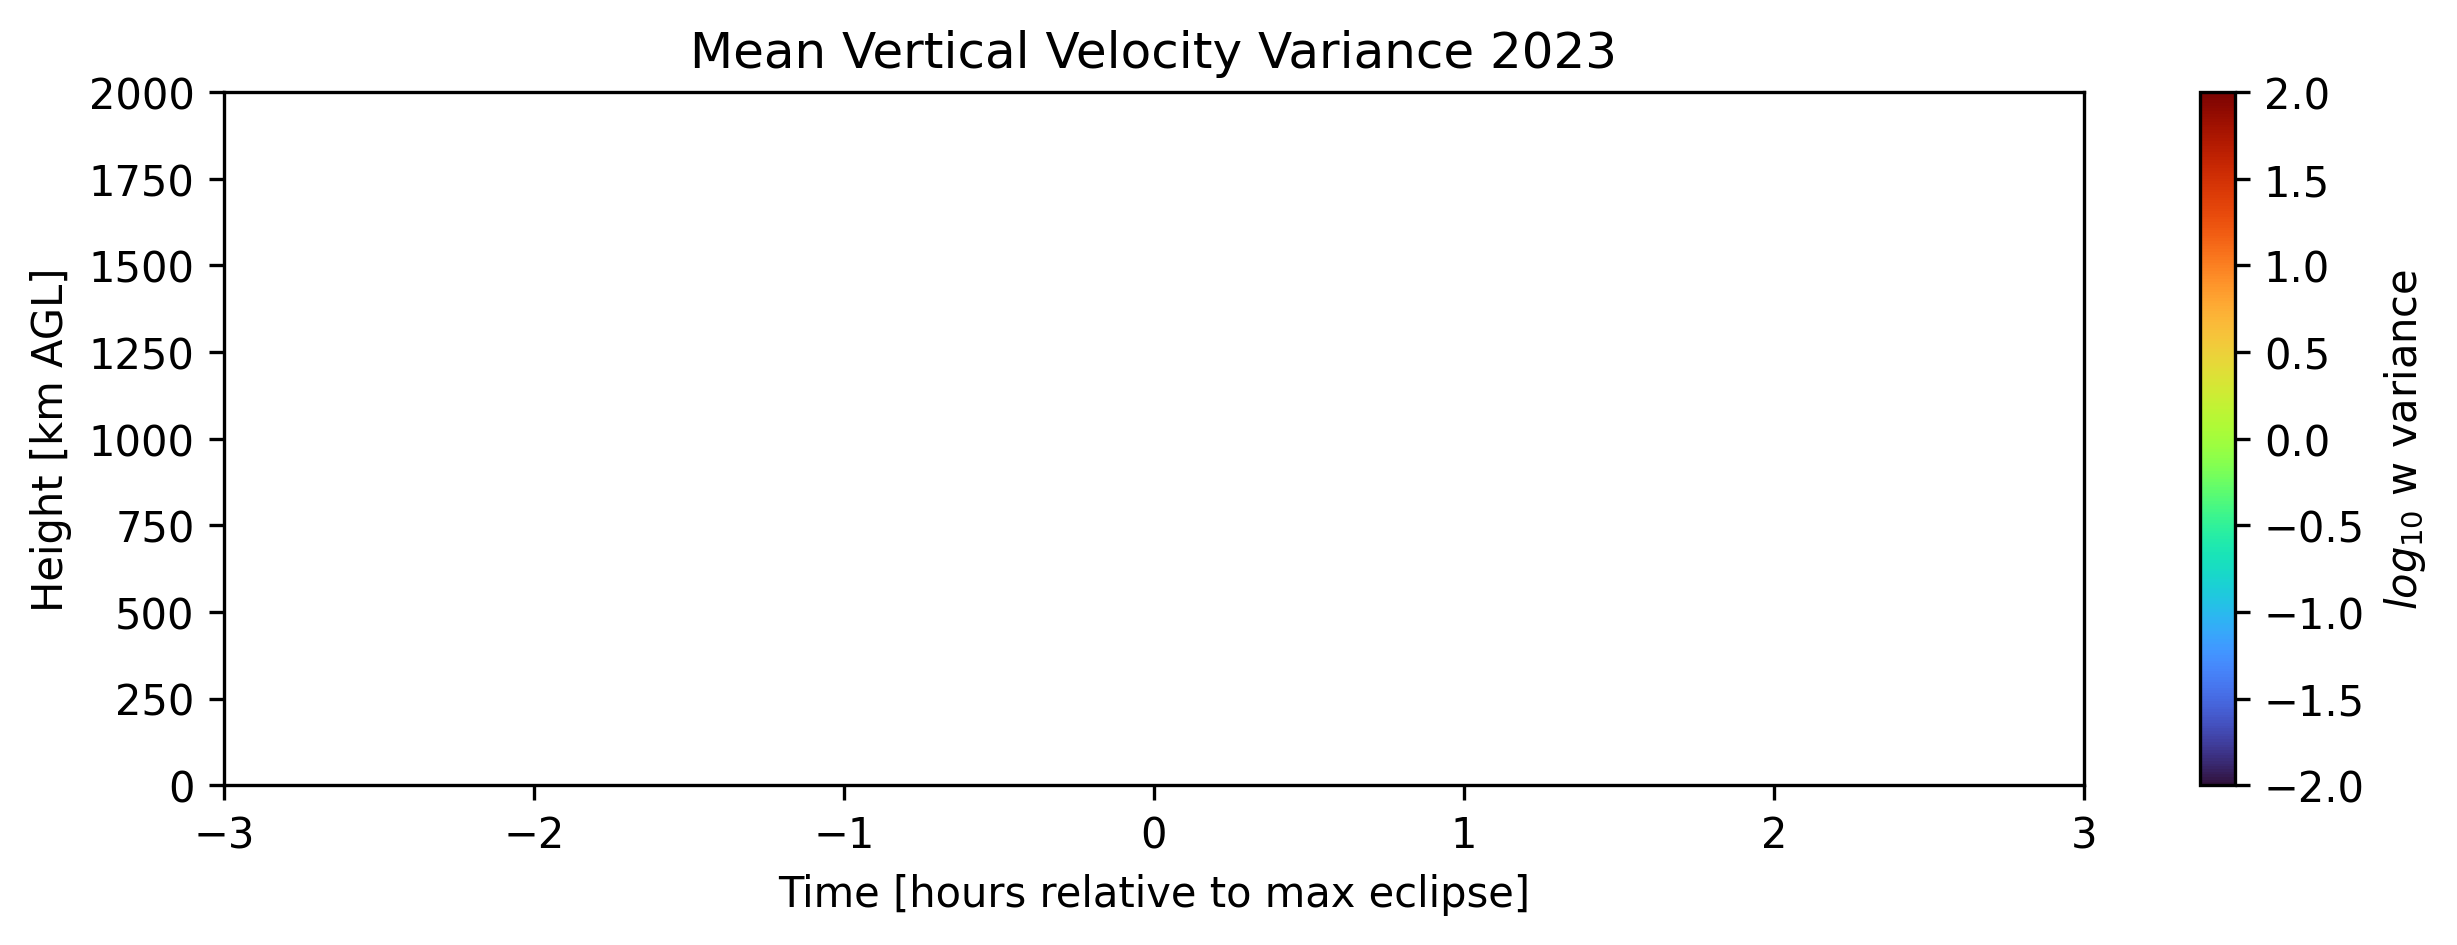

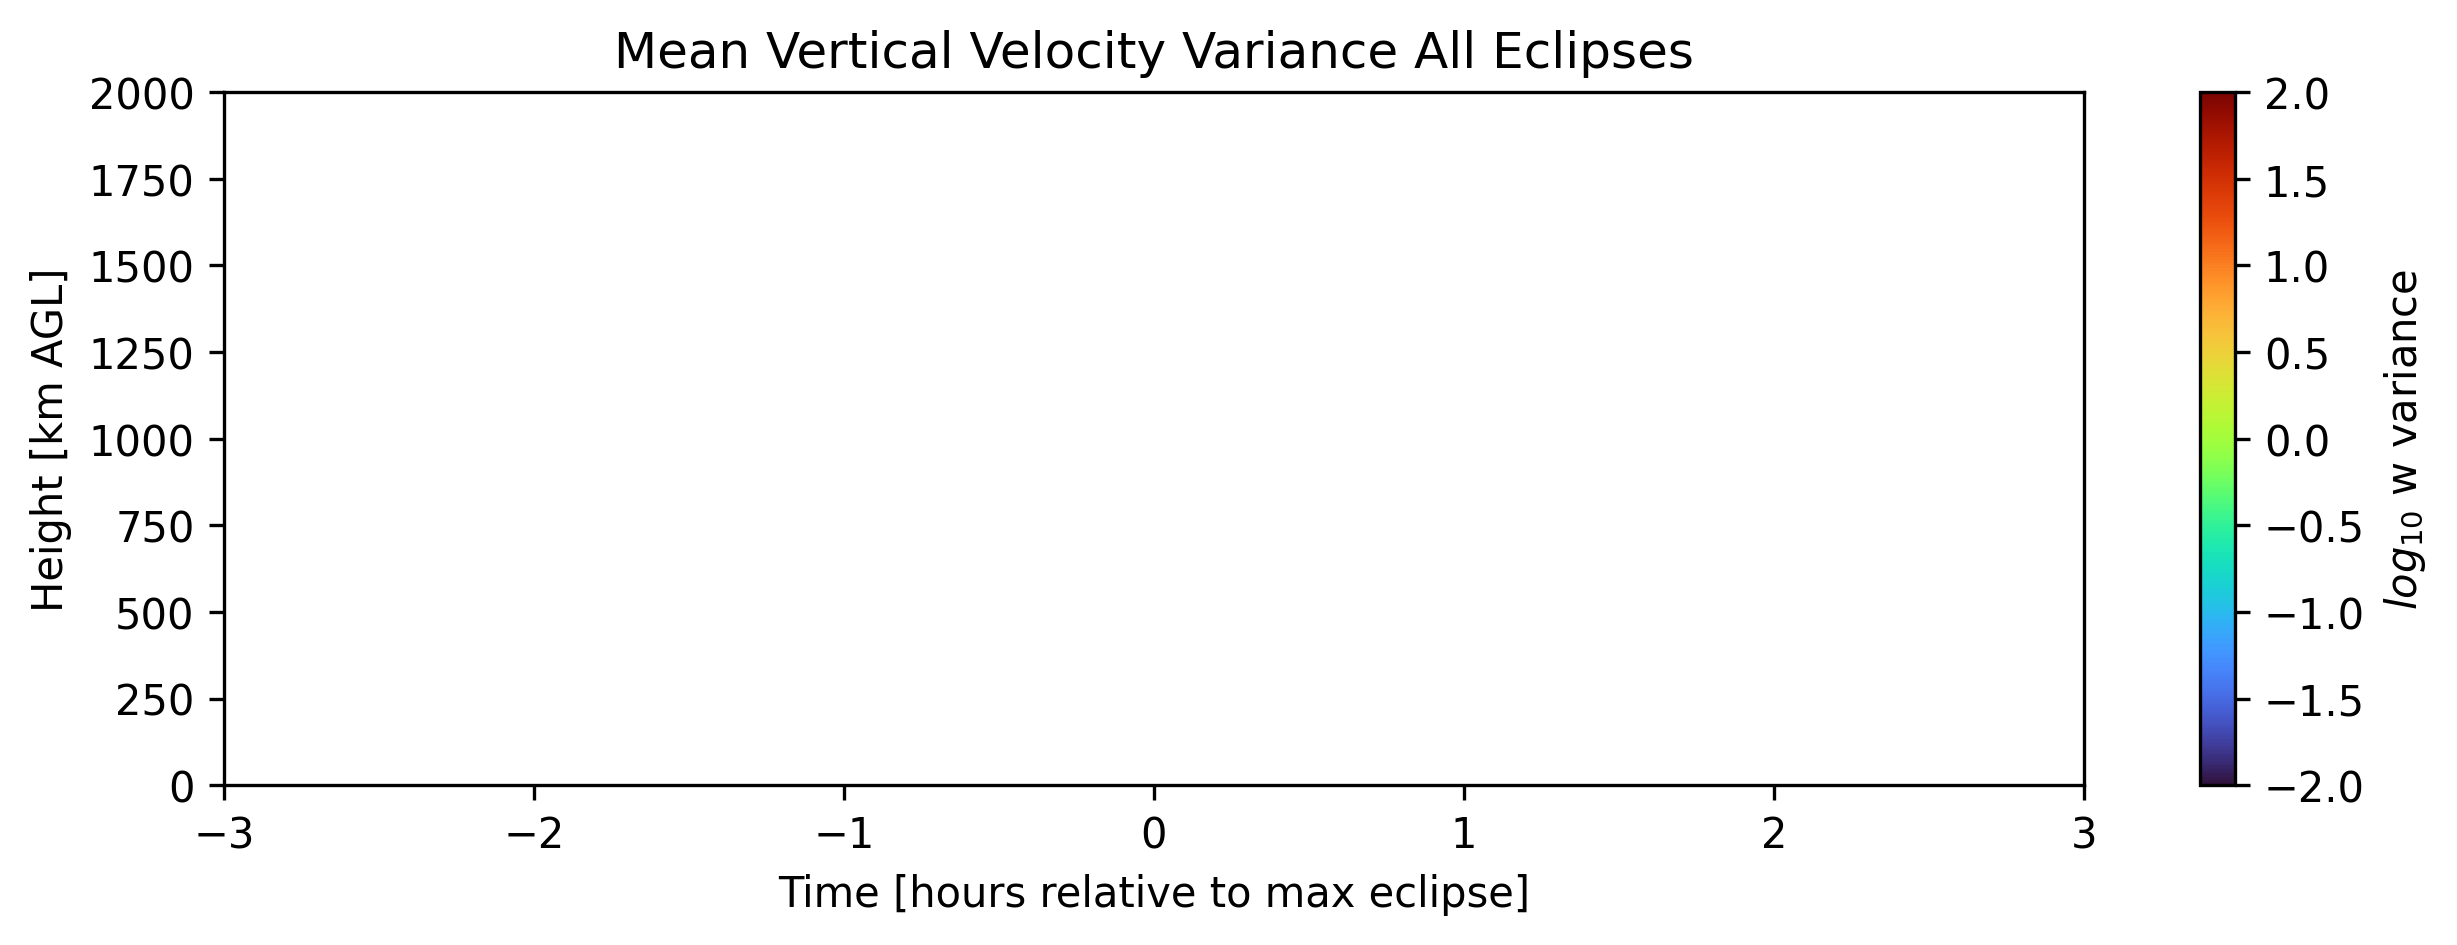

In [7]:
idx = np.where(saveDate ==20170821)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ w variance')
plt.title('Mean Vertical Velocity Variance 2017')
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [km AGL]')
plt.show()



idx = np.where(saveDate ==20231014)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ w variance')
plt.title('Mean Vertical Velocity Variance 2023')
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [km AGL]')
plt.show()


idx = np.where(saveDate > 2000)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ w variance')
plt.title('Mean Vertical Velocity Variance All Eclipses')
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [km AGL]')
plt.show()